In [2]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

In [3]:
data = load_diabetes()

In [4]:
df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

df.shape

(442, 11)

In [5]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [6]:
from sklearn.model_selection import train_test_split
X = df.drop('TARGET', axis=1)
y = df['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)


In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((353, 10), (353,), (89, 10), (89,))

1. How are coefficients affected?

In [8]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [9]:
coef = []
r2 = []

alphas = [0.1, 1, 10, 100, 1000, 10000, 100000]
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    coef.append(ridge_model.coef_)
    y_pred = ridge_model.predict(X_test)
    r2.append(r2_score(y_test, y_pred))


In [10]:
coef_df = pd.DataFrame(coef, columns=X.columns, index=alphas)
coef_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.1,31.033892,-204.830591,464.896345,304.964149,-95.760370,-87.529692,-183.818093,147.497940,425.853925,110.215599
1.0,42.955098,-67.887067,280.270383,195.506087,0.015036,-30.813126,-145.767246,114.715808,243.273028,120.912940
10.0,18.777884,0.364232,64.215213,49.175535,14.439729,9.623399,-40.539280,39.321539,59.201623,40.365253
100.0,2.508376,0.499954,7.600231,5.950702,2.220424,1.729273,-5.003424,5.100126,7.167275,5.128502
1000.0,0.259179,0.056343,0.774914,0.608267,0.232655,0.183516,-0.512558,0.525412,0.732780,0.527023
10000.0,0.026004,0.005700,0.077644,0.060962,0.023375,0.018461,-0.051382,0.052700,0.073443,0.052848
100000.0,0.002601,0.000571,0.007766,0.006098,0.002339,0.001847,-0.005139,0.005272,0.007346,0.005286


Text(0, 0.5, 'Coefficient Value')

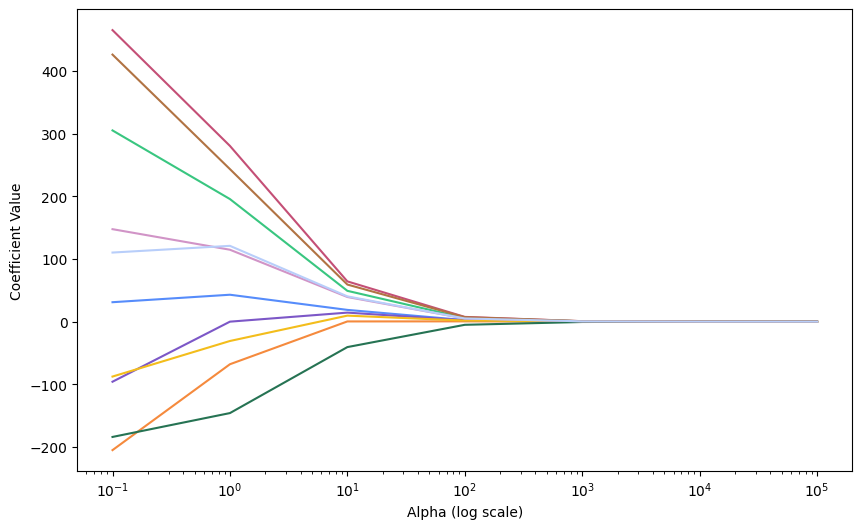

In [11]:
plt.figure(figsize=(10, 6))
for column in coef_df.columns:
    plt.plot(coef_df.index, coef_df[column], label=column)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')


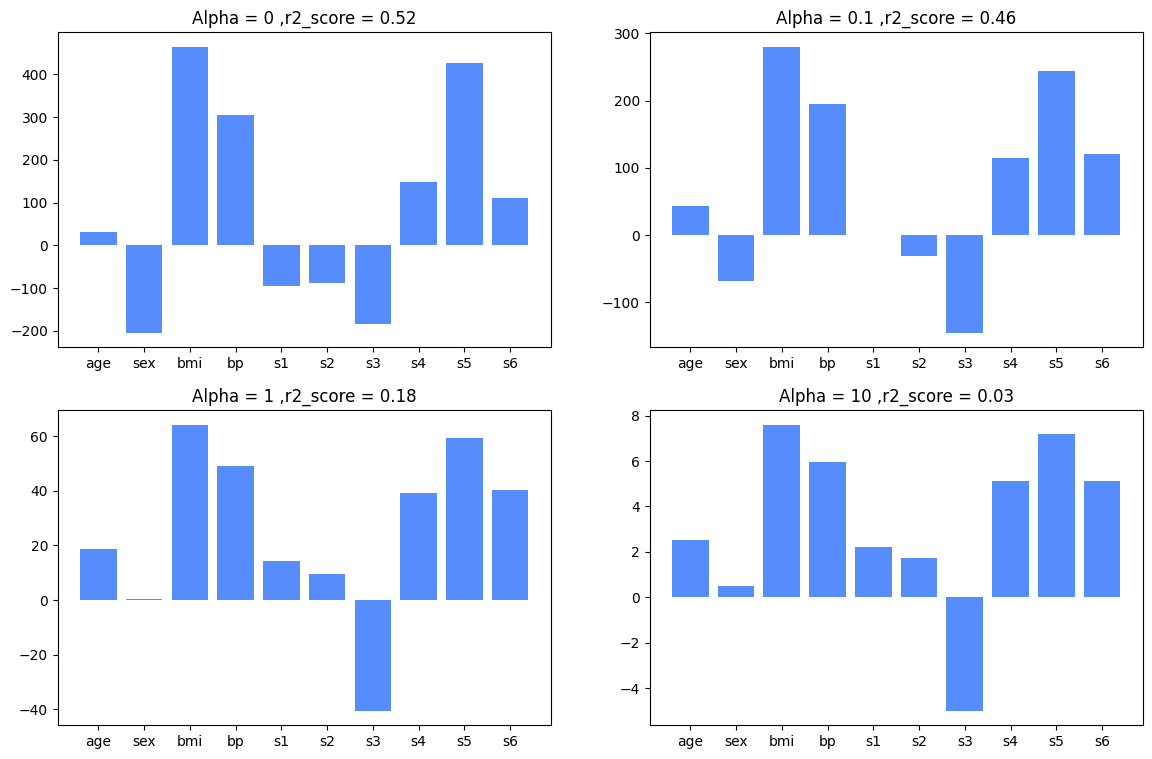

In [12]:
plt.figure(figsize=(14,9))
plt.subplot(221)

for alpha in alphas:
    plt.subplot(221)
    plt.bar(data.feature_names, coef[0])
    plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2[0],2)))

    plt.subplot(222)
    plt.bar(data.feature_names, coef[1])
    plt.title('Alpha = 0.1 ,r2_score = {}'.format(round(r2[1],2)))

    plt.subplot(223)
    plt.bar(data.feature_names, coef[2])
    plt.title('Alpha = 1 ,r2_score = {}'.format(round(r2[2],2)))

    plt.subplot(224)
    plt.bar(data.feature_names, coef[3])
    plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2[3],2)))
    break


2. Higher Coefficients are affected more

In [13]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]
coef = []
r2_ = []

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    coef.append(ridge_model.coef_)
    y_pred = ridge_model.predict(X_test)
    r2_.append(r2_score(y_test, y_pred))


In [14]:
coef_df = pd.DataFrame(coef, columns=X.columns, index=alphas)
coef_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.0000,23.454654,-247.427474,492.108752,329.358764,-970.797230,573.542955,182.421624,255.921682,794.216093,89.322492
0.0001,23.517635,-247.317667,492.282449,329.331759,-957.463244,562.903103,176.710702,254.470333,789.108676,89.413758
0.0010,24.016144,-246.406044,493.592860,329.088330,-852.767736,479.424669,131.866827,243.032920,748.964644,90.155083
0.0100,26.261811,-240.399342,496.575080,326.659983,-420.981791,137.891804,-53.056922,194.223144,581.450282,94.313693
0.1000,31.033892,-204.830591,464.896345,304.964149,-95.760370,-87.529692,-183.818093,147.497940,425.853925,110.215599
1.0000,42.955098,-67.887067,280.270383,195.506087,0.015036,-30.813126,-145.767246,114.715808,243.273028,120.912940
10.0000,18.777884,0.364232,64.215213,49.175535,14.439729,9.623399,-40.539280,39.321539,59.201623,40.365253
100.0000,2.508376,0.499954,7.600231,5.950702,2.220424,1.729273,-5.003424,5.100126,7.167275,5.128502
1000.0000,0.259179,0.056343,0.774914,0.608267,0.232655,0.183516,-0.512558,0.525412,0.732780,0.527023
10000.0000,0.026004,0.005700,0.077644,0.060962,0.023375,0.018461,-0.051382,0.052700,0.073443,0.052848


In [15]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())

In [16]:
input_array = np.array(coefs).T

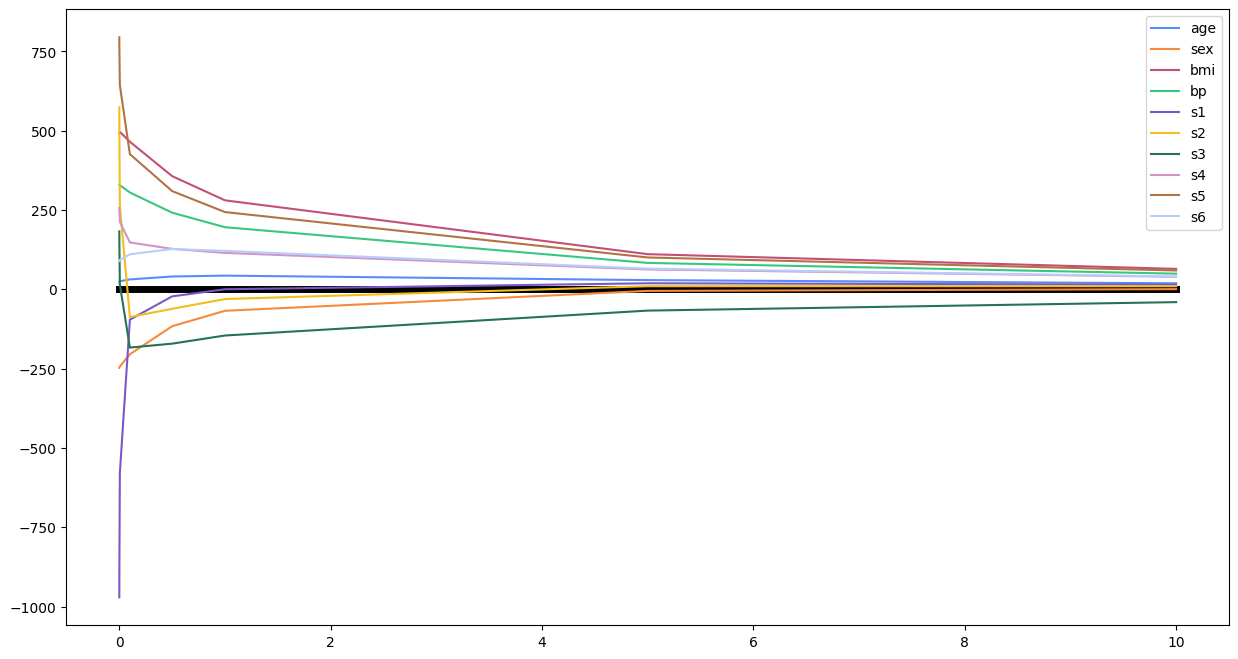

In [17]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()

3. Impact on Bias and Variance

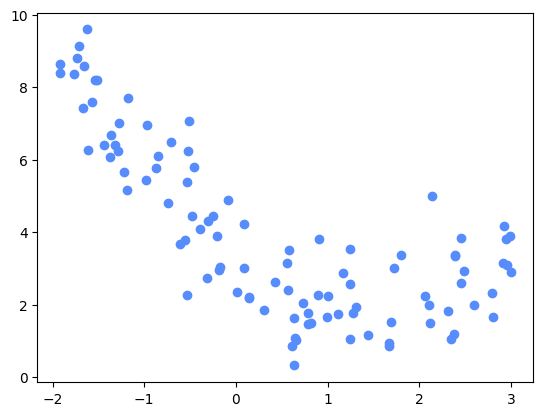

In [18]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [20]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [21]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=0.5)
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)

4. Effect of Regularization on Loss Function

[27.82809103]
-2.29474455867698


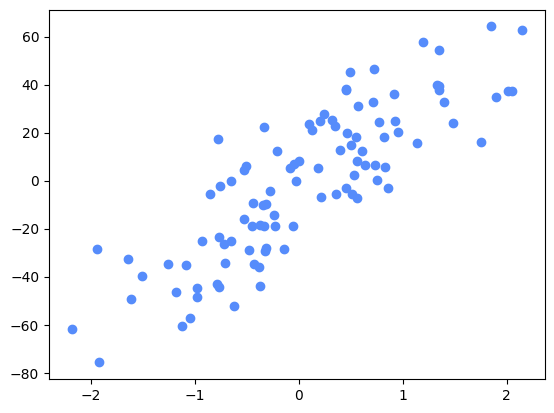

In [22]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [23]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

In [24]:
def predict(m):
    return m*X - 2.29

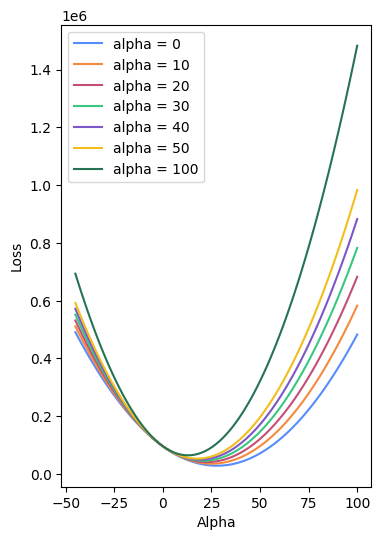

In [25]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(4,6))
for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.show()